# Validation of the EP solver on a test model with known singular points

This notebook tests `ep_search` (module `functions_QRM.jl`) on a **real, dense, non-normal** $72\times72$ matrix $A(x,y)$ with two parameters $(x,y)\in[0,1]^2$. Exceptional points (EP2), diabolic points (DP) and structures on the real axis are **planted with analytic laws**, so every result of the solver can be compared with the exact answer.

The model has the two properties of the QRM Liouvillian that the solver relies on: it is **real** (eigenvalues exactly real or in exact conjugate pairs), and its singular points come in both codimensions (real-axis EPs on curves, off-axis EPs at isolated points).

In [ ]:
using Revise
includet("Julia/NHQRM/functions_QRM.jl")
using .MyFunctions

using LinearAlgebra
using CairoMakie
using JLD2

CairoMakie.activate!(type = "png", px_per_unit = 2)
set_theme!(merge(theme_latexfonts(), Theme(size = (800, 500), fontsize = 20, figure_padding = 14,
    Axis = (xgridvisible = false, ygridvisible = false, xtickalign = 0, ytickalign = 0,
            xlabelsize = 24, ylabelsize = 24, xticklabelsize = 20, yticklabelsize = 20),
    Lines = (linewidth = 3,))))

## The model

$$A(x,y)=S\,B(x,y)\,S^{-1},\qquad B=\mathrm{blockdiag}(R_1,\dots,R_4,\;C_1,\dots,C_8,\;\text{background}).$$

- $S$ is a **fixed** real matrix with condition number 10: a product $Q_1DQ_2$ of two orthogonal matrices built from a deterministic formula (no random numbers, so the notebook is reproducible on any machine) and $D=\mathrm{diag}(10^{0\dots1})$. $A$ is dense and non-normal, and the block structure is invisible to the solver.
- A complex $n\times n$ block $C$ enters through its real $2n\times2n$ form $\begin{pmatrix}\mathrm{Re}\,C&-\mathrm{Im}\,C\\ \mathrm{Im}\,C&\mathrm{Re}\,C\end{pmatrix}$, whose spectrum is $\mathrm{spec}(C)\cup\overline{\mathrm{spec}(C)}$. $A$ is therefore real.
- Notation: $z=(x-x_0)+i(y-y_0)$ is the complex coordinate centred at the planted point $(x_0,y_0)$; $\delta=(\lambda_1-\lambda_2)/2$ for the coalescing pair.

### Real-axis structures (codimension 1: curves)

| block | matrix | eigenvalues | singular set | $\lambda^*$ | expected |
|---|---|---|---|---|---|
| $R_1$ | $\begin{pmatrix}\lambda&1\\f_1&\lambda\end{pmatrix}$, $f_1=(x-0.3071)^2+(y-0.5037)^2-0.1983^2$ | $\lambda\pm\sqrt{f_1}$ | **EP curve = circle** $f_1=0$ (real outside, complex inside) | $-0.20$ | EP2 on every crossing of a grid line |
| $R_2$ | $\begin{pmatrix}\lambda&\omega_2+c\\c-\omega_2&\lambda\end{pmatrix}$, $\omega_2=3[x-0.6513-0.3(y-0.5)^2]$, $c=10^{-6}$ | $\lambda\pm\sqrt{c^2-\omega_2^2}$ | **thin real strip** along a parabola, width $2c/3\approx7\cdot10^{-7}$ in $x$, bounded by the EP curves $\omega_2=\pm c$ | $-0.25$ | two weak EP2 ($t\approx2c$) per crossing, like the QRM strips |
| $R_3$ | same form, $\omega_3=2[(x-0.8537)+0.1(y-0.5)]$, $c=0.02$ | $\lambda\pm\sqrt{c^2-\omega_3^2}$ | **wide tilted strip**, width $0.02$ (≈ one coarse grid step) | $-0.35$ | two EP2 per crossing |
| $R_4$ | $\begin{pmatrix}\lambda&\omega_4\\-\omega_4&\lambda\end{pmatrix}$, $\omega_4=2[y-0.2-0.1\sin 2\pi x]$ | $\lambda\pm i\omega_4$ (normal) | conjugate pair **touching** the axis on the curve $\omega_4=0$: a **DP line** | $-0.30$ | **no EP** (near misses "touching", or DP) |

In addition, the real eigenvalue $-0.2+\sqrt{f_1}$ of $R_1$ leaves the Re-window $[-1,0]$ through $\mathrm{Re}\,\lambda=0$: this changes the count of real eigenvalues without any coalescence, and must be rejected.

### Off-axis structures (codimension 2: points)

| block | law | point(s) $(x_0,y_0)$ | $\lambda^*$ | winding index | expected |
|---|---|---|---|---|---|
| $C_1$ | $\begin{pmatrix}\mu&1\\z&\mu\end{pmatrix}$: $\delta^2=z$ | $(0.2317,\,0.3683)$ | $-0.15+0.50i$ | $+1$ | EP2 |
| $C_2$ | $\begin{pmatrix}\mu&1\\\bar z&\mu\end{pmatrix}$: $\delta^2=\bar z$ | $(0.2433,\,0.3571)$ — **same coarse cell as $C_1$** | $-0.35+0.70i$ | $-1$ | EP2 (may cancel with $C_1$ on the coarse grid) |
| $C_3$ | $\begin{pmatrix}\mu+z&t\\t&\mu-z\end{pmatrix}$, $t=10^{-4}$: $\delta^2=z^2+t^2$ | $(0.7137,\,0.2261\pm10^{-4})$: **two weak EP2 $2\cdot10^{-4}$ apart** | $-0.40+0.30i$ | $+1,+1$ (the cell has $+2$, like a DP) | 2 EP2, separated by the refinement |
| $C_4$ | $\begin{pmatrix}\mu&1\\z^2-a^2&\mu\end{pmatrix}$, $a=0.05$ | $(0.4127\pm0.05,\,0.6519)$: **two EP2 of the same block** | $-0.55+0.60i$ | $+1,+1$ | 2 EP2 |
| $C_5$ | $\delta^2=\sinh 3u-i\,v\,(1+u^2)$, $u=x-x_0$, $v=y-y_0$ (anisotropic, nonlinear) | $(0.1473,\,0.8261)$ | $-0.20+0.90i$ | $-1$ | EP2 |
| $C_6$ | $\begin{pmatrix}\mu&10^{-2}\\10^{-2}z&\mu\end{pmatrix}$: $\delta^2=10^{-4}z$ | $(0.5517,\,0.6173)$, **close to the real axis** ($\mathrm{Im}\,\lambda^*=0.02$) | $-0.50+0.02i$ | $+1$ | EP2 |
| $C_7$ | $\mathrm{diag}(\mu+z,\mu-z)$: $\delta=z$ | $(0.5531,\,0.8147)$ | $-0.10+1.10i$ | $+2$ | DP (conical) |
| $C_8$ | $\mathrm{diag}(\mu+w,\mu-w)$, $w=\bar z(1+z/2)$ | $(0.8311,\,0.4329)$ | $-0.65+0.95i$ | $-2$ | DP |

**Total planted off-axis zeros: 10** (8 EP2 + 2 DP).

### Background ("noise")

16 complex eigenvalues moving **linearly**, $\lambda_k(x,y)=b_k+b^x_kx+b^y_ky$ (32 real eigenvalues with the conjugates), with fixed coefficients chosen to give a dense spectrum in the window:

- **13 analytic DPs** inside the square (crossings $\lambda_k=\lambda_l$, solved exactly; index $\pm2$ from the orientation of the linear map), one of them close to the left edge ($x\approx0.011$, inside the first grid cell);
- **3 eigenvalues crossing the real axis** (normal pairs touching the axis: DP lines, no EP);
- many **crossings between background and planted eigenvalues** (different blocks ⇒ DPs). Their positions are not predicted analytically; the check verifies that each one is a crossing between two different eigenvalues of $B$, with index $\pm2$ and verdict DP.

### What the solver must reproduce

1. every crossing of a grid line with the EP curves of $R_1$, $R_2$, $R_3$ (positions $<10^{-9}$), all EP2, and nothing else on the real axis; $R_4$ and the background axis crossings must not produce EP2;
2. the 10 planted off-axis zeros, with the right winding index and verdict (the $C_1$/$C_2$ pair may cancel on the coarse grid, and must then be missing *together*);
3. the 13 analytic background DPs (index $\pm2$, DP), and only DPs among the remaining zeros;
4. blind regions only where a real-axis EP curve passes. A grid cell crossed by one is split 4 times, so what remains blind are small sub-cells (side = cell/16) along the curve; a line that only touches the axis (R4, background) must not create any.

The test runs on two grids, $41\times41$ (step 0.025) and $101\times101$ (step 0.01).

In [40]:
# ── the model ─────────────────────────────────────────────────────────────────────────────
realify(C) = [real(C) -imag(C); imag(C) real(C)]    # complex n×n → real 2n×2n; spectrum = spec(C) ∪ conj
zc(x, y, P) = (x - P[1]) + im * (y - P[2])          # complex coordinate centred at P

# real-axis structures (λ* real)
R1 = (xc = 0.3071, yc = 0.5037, r = 0.1983, λ = -0.20)              # EP curve = circle
f1(x, y) = (x - R1.xc)^2 + (y - R1.yc)^2 - R1.r^2                   # eigenvalues λ ± √f1
R2 = (x0 = 0.6513, a = 0.3, c = 1e-6, λ = -0.25)                    # thin real strip along a parabola
ω2(x, y) = 3 * (x - (R2.x0 + R2.a * (y - 0.5)^2))                   # eigenvalues λ ± √(c² - ω²)
R3 = (x0 = 0.8537, tilt = 0.1, c = 0.02, λ = -0.35)                 # wide tilted real strip
ω3(x, y) = 2 * ((x - R3.x0) + R3.tilt * (y - 0.5))                  # eigenvalues λ ± √(c² - ω²)
R4 = (λ = -0.30,)                                                   # normal pair touching the axis (DP line)
ω4(x, y) = 2 * (y - (0.2 + 0.1 * sin(2π * x)))                      # eigenvalues λ ± iω

# off-axis structures
C1 = (P = (0.2317, 0.3683), μ = -0.15 + 0.50im)                     # EP2, δ² = z          (index +1)
C2 = (P = (0.2433, 0.3571), μ = -0.35 + 0.70im)                     # EP2, δ² = z̄          (index -1)
C3 = (P = (0.7137, 0.2261), μ = -0.40 + 0.30im, tw = 1e-4)          # two weak EP2, δ² = z² + tw²
C4 = (P = (0.4127, 0.6519), μ = -0.55 + 0.60im, a = 0.05)           # two EP2 of one block, δ² = z² - a²
C5 = (P = (0.1473, 0.8261), μ = -0.20 + 0.90im)                     # EP2, anisotropic & nonlinear (index -1)
δ2_C5(x, y) = sinh(3(x - C5.P[1])) - im * (y - C5.P[2]) * (1 + (x - C5.P[1])^2)
C6 = (P = (0.5517, 0.6173), μ = -0.50 + 0.02im)                     # EP2 close to the real axis, δ² = 1e-4 z
C7 = (P = (0.5531, 0.8147), μ = -0.10 + 1.10im)                     # conical DP, δ = z            (index +2)
C8 = (P = (0.8311, 0.4329), μ = -0.65 + 0.95im)                     # DP, δ = z̄(1 + z/2)          (index -2)
w8(x, y) = conj(zc(x, y, C8.P)) * (1 + zc(x, y, C8.P) / 2)

# background: 16 eigenvalues moving linearly, λ_k = b0 + bx·x + by·y (fixed coefficients)
b0 = ComplexF64[-0.4123 + 0.5283im, -0.2548 + 0.6899im, -0.2891 + 0.1979im, -0.6272 + 1.0032im, -0.4703 + 0.3932im,
                -0.2147 + 1.0087im, -0.5172 + 0.4456im, -0.7004 + 0.1037im, -0.8402 + 0.3033im, -0.1592 + 0.7706im,
                -0.3647 + 1.0377im, -0.7429 + 0.3597im, -0.8108 + 0.0721im, -0.589 + 0.6658im, -0.4482 + 0.8871im,
                -0.5841 + 0.8571im]
bx = ComplexF64[-0.3026 + 0.3403im, -0.1498 + 0.4895im, -0.175 + 0.445im, 0.1226 + 0.4184im, 0.0837 - 0.4041im,
                0.0516 - 0.2727im, -0.27 - 0.0024im, 0.0957 - 0.4057im, 0.3206 + 0.0265im, 0.3686 + 0.1546im,
                0.3077 + 0.2479im, 0.2471 + 0.0644im, 0.1005 - 0.3417im, -0.3929 - 0.2987im, -0.2459 + 0.2511im,
                -0.2658 + 0.4574im]
by = ComplexF64[0.21 - 0.1394im, -0.1499 - 0.4295im, 0.1895 - 0.188im, 0.045 - 0.2634im, 0.1717 - 0.3283im,
                0.1533 + 0.3805im, -0.1571 - 0.3978im, 0.0027 + 0.4083im, 0.0963 - 0.2825im, -0.4745 + 0.0709im,
                -0.1612 - 0.3265im, 0.3479 + 0.4744im, -0.2196 + 0.3658im, 0.1102 + 0.3692im, -0.281 - 0.3207im,
                0.0594 - 0.469im]
bg(x, y) = b0 .+ bx .* x .+ by .* y

function blocks(x, y)
    z(C) = zc(x, y, C.P)
    return [
        [R1.λ 1.0; f1(x, y) R1.λ],                                                   #  1  R1
        [R2.λ (ω2(x, y) + R2.c); (R2.c - ω2(x, y)) R2.λ],                              #  2  R2
        [R3.λ (ω3(x, y) + R3.c); (R3.c - ω3(x, y)) R3.λ],                              #  3  R3
        [R4.λ ω4(x, y); -ω4(x, y) R4.λ],                                               #  4  R4
        realify(ComplexF64[C1.μ 1; z(C1) C1.μ]),                                       #  5  C1
        realify(ComplexF64[C2.μ 1; conj(z(C2)) C2.μ]),                                 #  6  C2
        realify(ComplexF64[C3.μ+z(C3) C3.tw; C3.tw C3.μ-z(C3)]),                       #  7  C3
        realify(ComplexF64[C4.μ 1; z(C4)^2-C4.a^2 C4.μ]),                              #  8  C4
        realify(ComplexF64[C5.μ 1; δ2_C5(x, y) C5.μ]),                                 #  9  C5
        realify(ComplexF64[C6.μ 1e-2; 1e-2*z(C6) C6.μ]),                               # 10  C6
        realify(Diagonal(ComplexF64[C7.μ + z(C7), C7.μ - z(C7)])),                     # 11  C7
        realify(Diagonal(ComplexF64[C8.μ + w8(x, y), C8.μ - w8(x, y)])),               # 12  C8
        realify(Diagonal(bg(x, y))),                                                   # 13  background
    ]
end

# fixed similarity (deterministic, cond = 10): dense, non-normal, block structure hidden
NTOT = sum(size(b, 1) for b in blocks(0.5, 0.5))
Mdet = [sin(1.3i + 0.7j^1.1) + 0.3cos(0.9i * j) for i in 1:NTOT, j in 1:NTOT]
S    = Matrix(qr(Mdet).Q) * Diagonal(10 .^ range(0, 1, NTOT)) * Matrix(qr(Mdet').Q)
Sinv = inv(S)
toymat(pt) = S * cat(blocks(pt.x, pt.y)...; dims = (1, 2)) * Sinv

println("matrix size ", NTOT, ",  cond(S) = ", round(cond(S), digits = 3),
        ",  ‖imag‖ = 0 (real matrix): ", eltype(toymat((x = 0.3, y = 0.4))))

matrix size 72,  cond(S) = 10.0,  ‖imag‖ = 0 (real matrix): Float64


In [41]:
# ── ground truth ──────────────────────────────────────────────────────────────────────────
# roots of h on [a, b]: sign changes on a fine sampling, refined by bisection
function roots1d(h, a, b; n = 20_001)
    xs = range(a, b, n); hs = h.(xs); out = Float64[]
    for k in 1:n-1
        hs[k] == 0 && (push!(out, xs[k]); continue)
        if hs[k+1] != 0 && sign(hs[k]) != sign(hs[k+1])
            lo, hi, flo = xs[k], xs[k+1], hs[k]
            for _ in 1:200
                m = (lo + hi) / 2; fm = h(m)
                sign(fm) == sign(flo) ? (lo = m; flo = fm) : (hi = m)
                hi - lo < 1e-15 && break
            end
            push!(out, (lo + hi) / 2)
        end
    end
    return out
end

# real-axis EP curves (zero sets) and their λ*
real_curves = [(name = "R1 circle",            h = f1,                               λ = R1.λ),
               (name = "R2 thin strip, ω = -c", h = (x, y) -> ω2(x, y) + R2.c,        λ = R2.λ),
               (name = "R2 thin strip, ω = +c", h = (x, y) -> ω2(x, y) - R2.c,        λ = R2.λ),
               (name = "R3 wide strip, ω = -c", h = (x, y) -> ω3(x, y) + R3.c,        λ = R3.λ),
               (name = "R3 wide strip, ω = +c", h = (x, y) -> ω3(x, y) - R3.c,        λ = R3.λ)]

# expected real-axis EPs on the grid lines of p: along x (lines y = const) and along y (lines x = const)
function expected_real(p)
    out = NamedTuple[]
    for c in real_curves
        for y in p.y, x in roots1d(x -> c.h(x, y), first(p.x), last(p.x))
            push!(out, (curve = c.name, λ = c.λ, along = :x, x = x, y = y))
        end
        for x in p.x, y in roots1d(y -> c.h(x, y), first(p.y), last(p.y))
            push!(out, (curve = c.name, λ = c.λ, along = :y, x = x, y = y))
        end
    end
    return out
end

# planted off-axis zeros
planted = [
    (name = "C1  EP2, δ² = z",                P = C1.P,                         λ = C1.μ, index = +1, type = "EP2"),
    (name = "C2  EP2, δ² = z̄",                P = C2.P,                         λ = C2.μ, index = -1, type = "EP2"),
    (name = "C3a weak EP2, δ² = z² + t²",     P = (C3.P[1], C3.P[2] + C3.tw),   λ = C3.μ, index = +1, type = "EP2"),
    (name = "C3b weak EP2, δ² = z² + t²",     P = (C3.P[1], C3.P[2] - C3.tw),   λ = C3.μ, index = +1, type = "EP2"),
    (name = "C4a EP2, δ² = z² - a²",          P = (C4.P[1] + C4.a, C4.P[2]),    λ = C4.μ, index = +1, type = "EP2"),
    (name = "C4b EP2, δ² = z² - a²",          P = (C4.P[1] - C4.a, C4.P[2]),    λ = C4.μ, index = +1, type = "EP2"),
    (name = "C5  EP2, anisotropic nonlinear", P = C5.P,                         λ = C5.μ, index = -1, type = "EP2"),
    (name = "C6  EP2 near the real axis",     P = C6.P,                         λ = C6.μ, index = +1, type = "EP2"),
    (name = "C7  conical DP",                 P = C7.P,                         λ = C7.μ, index = +2, type = "DP"),
    (name = "C8  DP, δ = z̄(1 + z/2)",         P = C8.P,                         λ = C8.μ, index = -2, type = "DP"),
]

# background DPs, analytic: λ_k = λ_l (or λ_k = conj λ_l) is a linear system in (x, y). The index is
# 2·sign(det of the linear map of δ), flipped if the crossing value lies in the lower half-plane
# (the solver works with the upper half-plane, where the pair is the conjugate one).
function background_dps()
    out = NamedTuple[]
    for k in 1:length(b0)-1, l in k+1:length(b0), cj in (false, true)
        c0 = b0[k] - (cj ? conj(b0[l]) : b0[l])
        a  = bx[k] - (cj ? conj(bx[l]) : bx[l]); b = by[k] - (cj ? conj(by[l]) : by[l])
        A  = [real(a) real(b); imag(a) imag(b)]
        abs(det(A)) < 1e-12 && continue
        x, y = A \ [-real(c0); -imag(c0)]
        (0 < x < 1 && 0 < y < 1) || continue
        v = b0[k] + bx[k] * x + by[k] * y
        abs(imag(v)) < 1e-12 && continue
        s = sign(det(A)) * sign(imag(v))
        push!(out, (name = "bg $k-$l$(cj ? "*" : "")", P = (x, y), λ = imag(v) > 0 ? v : conj(v),
                    index = 2 * Int(s), type = "DP"))
    end
    return out
end

# which eigenvalues of B (block, index) coincide with λ at (x, y)? (ground truth for "DP between different eigenvalues")
function owners(x, y, λ; tol = 1e-5)
    own = Tuple{Int,Int}[]
    for (kb, Bk) in enumerate(blocks(x, y)), (ke, μ) in enumerate(eigvals(Bk))
        abs(μ - λ) < tol && push!(own, (kb, ke))
    end
    return own
end

# is an unreliable sub-rectangle (bounds c.cell = (x_min, x_max, y_min, y_max)) crossed by a real-axis
# EP curve (R1, R2, R3)?
function explained(c)
    xs = range(c.cell[1], c.cell[2], 9); ys = range(c.cell[3], c.cell[4], 9)
    changes(v) = any(<(0), v) && any(>(0), v)
    return changes([f1(x, y) for x in xs, y in ys]) || changes([ω2(x, y) for x in xs, y in ys]) ||
           changes([abs(ω3(x, y)) - R3.c for x in xs, y in ys])
end

BG = background_dps()
println("planted off-axis zeros: ", length(planted), "   analytic background DPs: ", length(BG))
for t in BG
    println("   ", rpad(t.name, 9), " (x, y) = (", round(t.P[1], digits = 4), ", ", round(t.P[2], digits = 4), ")  λ = ",
            round(t.λ, digits = 4), "  index ", t.index)
end
for n in (41, 101)
    E = expected_real((x = range(0, 1, n), y = range(0, 1, n)))
    println("grid $n×$n: expected real-axis EPs on the grid lines: ",
            join(["$(c.name): $(count(e -> e.curve == c.name, E))" for c in real_curves], ", "))
end

planted off-axis zeros: 10   analytic background DPs: 13
   bg 1-12   (x, y) = (0.4785, 0.4898)  λ = -0.4543 + 0.6229im  index 2
   bg 2-12   (x, y) = (0.4853, 0.5936)  λ = -0.4165 + 0.6725im  index 2
   bg 3-12   (x, y) = (0.9598, 0.3072)  λ = -0.3988 + 0.5673im  index 2
   bg 4-14   (x, y) = (0.1653, 0.7207)  λ = -0.5745 + 0.8825im  index -2
   bg 6-10   (x, y) = (0.9797, 0.5831)  λ = -0.0748 + 0.9634im  index 2
   bg 7-8    (x, y) = (0.259, 0.5537)  λ = -0.6741 + 0.2247im  index 2
   bg 7-12   (x, y) = (0.3678, 0.0703)  λ = -0.6276 + 0.4167im  index 2
   bg 7-13   (x, y) = (0.9459, 0.9094)  λ = -0.9154 + 0.0816im  index 2
   bg 8-9    (x, y) = (0.3978, 0.5378)  λ = -0.6609 + 0.1619im  index -2
   bg 12-16  (x, y) = (0.0106, 0.5316)  λ = -0.5553 + 0.6126im  index 2
   bg 14-15  (x, y) = (0.093, 0.3948)  λ = -0.582 + 0.7838im  index 2
   bg 14-16  (x, y) = (0.0824, 0.3025)  λ = -0.588 + 0.7529im  index -2
   bg 15-16  (x, y) = (0.4514, 0.4256)  λ = -0.6788 + 0.8639im  index -2
grid 41

## Run

`ep_search(toymat, p)` is the same call used for the QRM (the generic form, with a matrix map instead of the Liouvillian). Real-axis window $\mathrm{Re}\,\lambda\in[-1,0]$. The results are saved with JLD2.

In [42]:
p41  = (x = range(0.0, 1.0, 41),  y = range(0.0, 1.0, 41))
p101 = (x = range(0.0, 1.0, 101), y = range(0.0, 1.0, 101))
toy_kw = (re_window = (-1.0, 0.0), im_cap = 0.05)

R41  = ep_search(toymat, p41;  toy_kw...);  jldsave("toy_R41.jld2";  R = R41)
R101 = ep_search(toymat, p101; toy_kw...);  jldsave("toy_R101.jld2"; R = R101)
for (n, R) in ((41, R41), (101, R101))
    t = R.meta.timing
    println("grid $n×$n:  ", length(R.eps), " EP2, ", length(R.dps), " DP, ", length(R.inconclusive), " inconclusive;  time [s]: ",
            "spectra ", round(t.spectra, digits = 1), ", real ", round(t.real, digits = 1), ", off-axis ", round(t.complex, digits = 1),
            ", checks ", round(t.checks + t.records, digits = 1), "  (", R.meta.nthreads, " threads)")
end

[1/5] spectra (nodes)             100%|███| Time: 0:00:00 ( 0.12 ms/it)
[2/5] real axis (grid lines)      100%|███| Time: 0:00:08 (97.97 ms/it)
[3/5] off axis (edge phases)      100%|███| Time: 0:01:24 (25.71 ms/it)
[4/5] off axis (cell refinement)  100%|███| Time: 0:03:20 ( 0.65  s/it)
[5/5] checks (approach test)      100%|███| Time: 0:00:11 (24.58 ms/it)
[1/5] spectra (nodes)             100%|███| Time: 0:00:00 (75.39 μs/it)
[2/5] real axis (grid lines)      100%|███| Time: 0:00:18 (91.32 ms/it)
[3/5] off axis (edge phases)      100%|███| Time: 0:02:51 ( 8.48 ms/it)
[4/5] off axis (cell refinement)  100%|███| Time: 0:03:05 ( 0.31  s/it)
[5/5] checks (approach test)      100%|███| Time: 0:00:19 (23.12 ms/it)


grid 41×41:  256 EP2, 208 DP, 0 inconclusive;  time [s]: spectra 0.2, real 8.0, off-axis 285.3, checks 11.5  (32 threads)
grid 101×101:  618 EP2, 221 DP, 0 inconclusive;  time [s]: spectra 0.8, real 18.5, off-axis 357.2, checks 19.5  (32 threads)


## Comparison with the analytic answer

In [43]:
function compare(R, p; name = "")
    println("\n══════════ ", name, " ══════════")
    nfail = Ref(0)
    report(ok, msg) = (println(ok ? "PASS  " : "FAIL  ", msg); ok || (nfail[] += 1))
    recs = vcat(R.eps, R.dps, R.inconclusive)

    # ── real axis ──
    E  = expected_real(p)
    Fr = filter(r -> r.kind == :real, recs)
    fixc(r) = r.along == :x ? r.point.y : r.point.x          # coordinate fixed on the grid line
    posc(r) = r.along == :x ? r.point.x : r.point.y          # coordinate along the line
    hit(e, r) = r.along == e.along && abs(fixc(r) - (e.along == :x ? e.y : e.x)) < 1e-12 &&
                abs(posc(r) - (e.along == :x ? e.x : e.y)) < 1e-9
    for (sname, λs) in (("R1 circle", R1.λ), ("R2 thin strip", R2.λ), ("R3 wide strip", R3.λ))
        Es = filter(e -> e.λ == λs, E)
        Fs = filter(r -> abs(r.λ - λs) < 1e-3, Fr)
        found = [any(r -> hit(e, r), Fs) for e in Es]
        spur  = filter(r -> !any(e -> hit(e, r), Es), Fs)
        report(all(found), "$sname: $(count(found)) / $(length(Es)) expected EPs found (position < 1e-9)")
        report(isempty(spur), "$sname: $(length(spur)) found points not on the analytic curves")
        report(all(r -> r.verdict == "EP2", Fs), "$sname: verdicts $(unique(getfield.(Fs, :verdict)))")
        for e in Es[.!found][1:min(end, 5)]; println("      missed: ", e); end
        for r in spur[1:min(end, 5)];         println("      spurious: ", r.point, "  λ = ", r.λ, "  ", r.verdict); end
    end
    fake = filter(r -> r.verdict == "EP2" && all(abs(r.λ - λs) ≥ 1e-3 for λs in (R1.λ, R2.λ, R3.λ)), Fr)
    report(isempty(fake), "R4 + background axis crossings (DPs on the real axis): $(length(fake)) false EP2 " *
                          "(near misses $(length(R.nearmiss)), touching $(count(e -> e.touching, R.nearmiss)); " *
                          "real-axis records classified DP: $(count(r -> r.verdict == "DP", Fr)))")

    # ── off axis ──
    Fc   = filter(r -> r.kind == :complex, recs)
    used = falses(length(Fc))
    close_(r, P, λ) = hypot(r.point.x - P[1], r.point.y - P[2]) < 1e-6 && abs(r.λ - λ) < 1e-4
    missing_planted = String[]
    for t in planted
        k = findall(r -> close_(r, t.P, t.λ), Fc)
        if isempty(k)
            push!(missing_planted, t.name); println("      not found: ", t.name)
            continue
        end
        used[k] .= true; r = Fc[k[1]]
        report(length(k) == 1 && r.index == t.index && r.verdict == t.type,
               "$(rpad(t.name, 32)) index $(r.index) (exp. $(t.index)), $(r.verdict), " *
               "|Δp| = $(round(hypot(r.point.x - t.P[1], r.point.y - t.P[2]), sigdigits = 2)), " *
               "|Δλ| = $(round(abs(r.λ - t.λ), sigdigits = 2)), t = $(round(r.t, sigdigits = 2))")
    end
    samecell = searchsortedlast(p.x, C1.P[1]) == searchsortedlast(p.x, C2.P[1]) &&
               searchsortedlast(p.y, C1.P[2]) == searchsortedlast(p.y, C2.P[2])
    m12   = count(n -> startswith(n, "C1") || startswith(n, "C2"), missing_planted)
    other = filter(n -> !(startswith(n, "C1") || startswith(n, "C2")), missing_planted)
    report(isempty(other) && (m12 == 0 || (m12 == 2 && samecell)),
           "planted zeros missing: $(length(missing_planted))" * (m12 == 2 && samecell ? " (C1 + C2 cancelled in their common cell: allowed)" : ""))

    nbad = 0; nmiss = 0
    for t in BG
        k = findall(r -> close_(r, t.P, t.λ), Fc)
        if isempty(k); nmiss += 1; println("      background DP not found: ", t.name, " at ", round.(t.P, digits = 4)); continue; end
        used[k] .= true; r = Fc[k[1]]
        (r.index == t.index && r.verdict == "DP") ||
            (nbad += 1; println("      background DP wrong: ", t.name, " index ", r.index, " (exp. ", t.index, "), ", r.verdict))
    end
    report(nmiss == 0 && nbad == 0, "analytic background DPs: $(length(BG) - nmiss) / $(length(BG)) found, $nbad with wrong index/verdict")

    extras = Fc[.!used]
    ok_x = [abs(r.index) == 2 && r.verdict == "DP" && length(unique(owners(r.point.x, r.point.y, r.λ))) ≥ 2 for r in extras]
    report(all(ok_x), "other zeros (background ↔ planted crossings): $(length(extras)), all DP with index ±2 between two different eigenvalues")
    for (r, o) in zip(extras, ok_x)
        o || println("      BAD: ", round.((r.point.x, r.point.y), digits = 6), "  λ = ", round(r.λ, digits = 5), "  index ", r.index,
                     "  ", r.verdict, "  owners ", owners(r.point.x, r.point.y, r.λ))
    end

    # ── diagnostics ──
    unexpl = filter(c -> !explained(c), R.unreliable)
    area   = sum((c.cell[2] - c.cell[1]) * (c.cell[4] - c.cell[3]) for c in R.unreliable; init = 0.0)
    report(isempty(unexpl), "unreliable: $(R.meta.n_unreliable_grid) of $(R.meta.n_cells) grid cells split; remaining blind " *
                            "sub-cells $(length(R.unreliable)) (area $(round(100area, sigdigits = 2)) % of the square); " *
                            "not crossed by a real-axis EP curve: $(length(unexpl))")
    report(isempty(R.unresolved), "unresolved sub-cells: $(length(R.unresolved))")
    println("   off-axis zeros outside the Re-window: ", R.n_outside)
    println("   ⇒ ", nfail[], " FAIL")
    return nfail[]
end

compare(R41, p41; name = "grid 41 × 41")


══════════ grid 41 × 41 ══════════
PASS  R1 circle: 64 / 64 expected EPs found (position < 1e-9)
PASS  R1 circle: 0 found points not on the analytic curves
PASS  R1 circle: verdicts ["EP2"]
PASS  R2 thin strip: 94 / 94 expected EPs found (position < 1e-9)
PASS  R2 thin strip: 0 found points not on the analytic curves
PASS  R2 thin strip: verdicts ["EP2"]
PASS  R3 wide strip: 90 / 90 expected EPs found (position < 1e-9)
PASS  R3 wide strip: 0 found points not on the analytic curves
PASS  R3 wide strip: verdicts ["EP2"]
PASS  R4 + background axis crossings (DPs on the real axis): 0 false EP2 (near misses 366, touching 295; real-axis records classified DP: 18)
PASS  C1  EP2, δ² = z                  index 1 (exp. 1), EP2, |Δp| = 1.9e-16, |Δλ| = 1.5e-15, t = 1.0
PASS  C2  EP2, δ² = z̄                  index -1 (exp. -1), EP2, |Δp| = 1.8e-16, |Δλ| = 1.0e-15, t = 1.0
PASS  C3a weak EP2, δ² = z² + t²       index 1 (exp. 1), EP2, |Δp| = 4.2e-16, |Δλ| = 4.6e-16, t = 0.0002
PASS  C3b weak EP2, δ

1

In [44]:
compare(R101, p101; name = "grid 101 × 101")


══════════ grid 101 × 101 ══════════
PASS  R1 circle: 160 / 160 expected EPs found (position < 1e-9)
PASS  R1 circle: 0 found points not on the analytic curves
PASS  R1 circle: verdicts ["EP2"]
FAIL  R2 thin strip: 228 / 230 expected EPs found (position < 1e-9)
PASS  R2 thin strip: 0 found points not on the analytic curves
PASS  R2 thin strip: verdicts ["EP2"]
      missed: (curve = "R2 thin strip, ω = -c", λ = -0.25, along = :x, x = 0.714779666666667, y = 0.04)
      missed: (curve = "R2 thin strip, ω = +c", λ = -0.25, along = :x, x = 0.7147803333333332, y = 0.04)
PASS  R3 wide strip: 222 / 222 expected EPs found (position < 1e-9)
PASS  R3 wide strip: 0 found points not on the analytic curves
PASS  R3 wide strip: verdicts ["EP2"]
PASS  R4 + background axis crossings (DPs on the real axis): 0 false EP2 (near misses 982, touching 809; real-axis records classified DP: 16)
PASS  C1  EP2, δ² = z                  index 1 (exp. 1), EP2, |Δp| = 3.4e-16, |Δλ| = 8.9e-16, t = 1.0
PASS  C2  EP2,

1

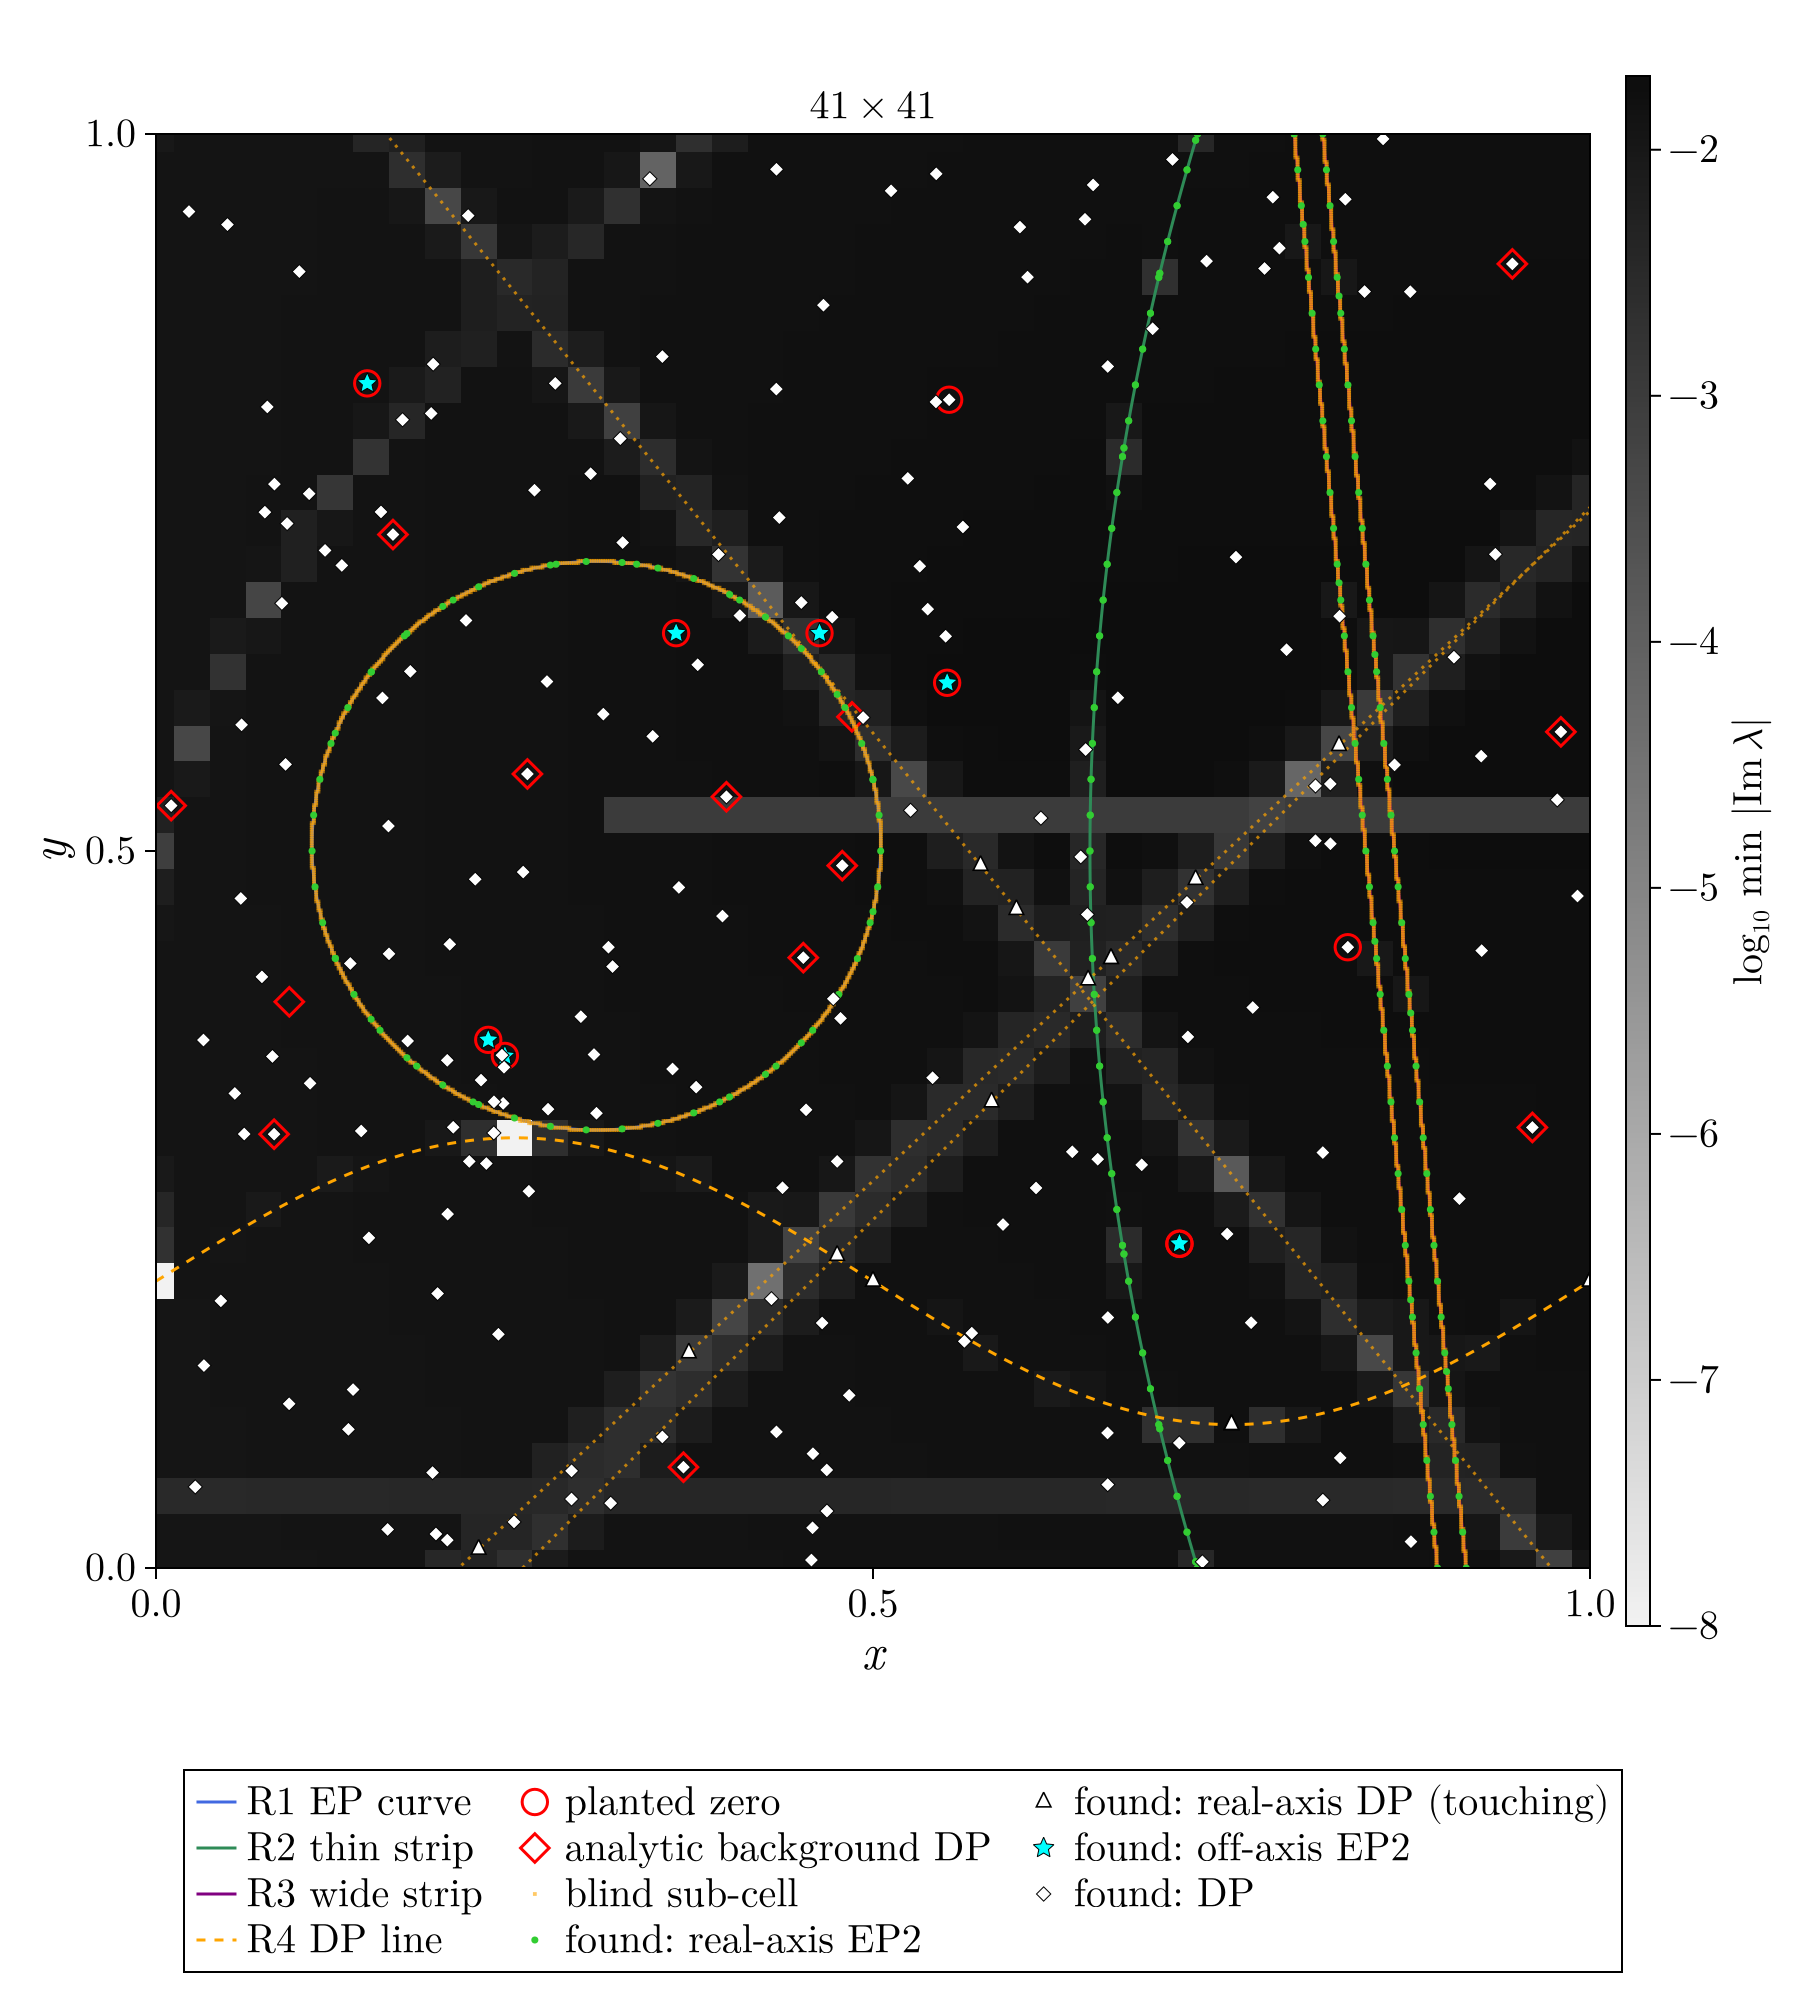

In [ ]:
# ── map: analytic structures (lines, hollow markers) vs solver (filled markers) ───────────────
function plot_toy(R; title = "")
    x, y = R.meta.axes
    fig = Figure(size = (900, 1000))
    ax  = Axis(fig[1, 1]; xlabel = L"x", ylabel = L"y", title = title, aspect = DataAspect(), limits = ((0, 1), (0, 1)))
    hm  = heatmap!(ax, x, y, log10.(clamp.(R.maps.imin, 1e-8, 1.0)); colormap = Reverse(:grays))
    Colorbar(fig[1, 2], hm; label = L"\log_{10}\,\min\,|\mathrm{Im}\,\lambda|")
    θ  = range(0, 2π, 400); yy = range(0, 1, 300); xx = range(0, 1, 400)
    lines!(ax, R1.xc .+ R1.r .* cos.(θ), R1.yc .+ R1.r .* sin.(θ); color = :royalblue, linewidth = 1.5, label = "R1 EP curve")
    lines!(ax, R2.x0 .+ R2.a .* (yy .- 0.5) .^ 2, yy; color = :seagreen, linewidth = 1.5, label = "R2 thin strip")
    lines!(ax, R3.x0 .- R3.tilt .* (yy .- 0.5) .- R3.c / 2, yy; color = :purple, linewidth = 1.5, label = "R3 wide strip")
    lines!(ax, R3.x0 .- R3.tilt .* (yy .- 0.5) .+ R3.c / 2, yy; color = :purple, linewidth = 1.5)
    lines!(ax, xx, 0.2 .+ 0.1 .* sin.(2π .* xx); color = :orange, linestyle = :dash, linewidth = 1.5, label = "R4 DP line")
    for k in eachindex(b0)                                   # background eigenvalues crossing the real axis
        abs(imag(by[k])) > 1e-9 || continue
        yk = @. -(imag(b0[k]) + imag(bx[k]) * xx) / imag(by[k]); m = 0 .≤ yk .≤ 1
        any(m) && lines!(ax, xx[m], yk[m]; color = (:orange, 0.7), linestyle = :dot, linewidth = 1.5)
    end
    scatter!(ax, [t.P[1] for t in planted], [t.P[2] for t in planted]; marker = :circle, markersize = 18,
             color = :transparent, strokecolor = :red, strokewidth = 1.5, label = "planted zero")
    scatter!(ax, [t.P[1] for t in BG], [t.P[2] for t in BG]; marker = :diamond, markersize = 16,
             color = :transparent, strokecolor = :red, strokewidth = 1.5, label = "analytic background DP")
    isempty(R.unreliable) || scatter!(ax, [c.point.x for c in R.unreliable], [c.point.y for c in R.unreliable];
                                      marker = :rect, markersize = 3, color = (:orange, 0.6), label = "blind sub-cell")
    re  = filter(r -> r.kind == :real, R.eps)                # real-axis EP2 only
    rdp = filter(r -> r.kind == :real, R.dps)                # real-axis points classified DP (touching the axis)
    cx  = filter(r -> r.kind == :complex, R.eps)
    dp  = filter(r -> r.kind == :complex, R.dps)
    isempty(re)  || scatter!(ax, [r.point.x for r in re], [r.point.y for r in re]; markersize = 5, color = :limegreen, label = "found: real-axis EP2")
    isempty(rdp) || scatter!(ax, [r.point.x for r in rdp], [r.point.y for r in rdp]; marker = :utriangle, markersize = 10,
                             color = :white, strokecolor = :black, strokewidth = 0.8, label = "found: real-axis DP (touching)")
    isempty(cx) || scatter!(ax, [r.point.x for r in cx], [r.point.y for r in cx]; marker = :star5, markersize = 12, color = :cyan,
                            strokecolor = :black, strokewidth = 0.5, label = "found: off-axis EP2")
    isempty(dp) || scatter!(ax, [r.point.x for r in dp], [r.point.y for r in dp]; marker = :diamond, markersize = 8, color = :white,
                            strokecolor = :black, strokewidth = 0.5, label = "found: DP")
    isempty(R.inconclusive) || scatter!(ax, [r.point.x for r in R.inconclusive], [r.point.y for r in R.inconclusive];
                                        marker = :xcross, markersize = 12, color = :red, label = "inconclusive")
    Legend(fig[2, 1:2], ax; orientation = :horizontal, nbanks = 4, tellheight = true, framevisible = true)
    return fig
end

fig41 = plot_toy(R41; title = L"41\times41")
save("Julia/NHQRM/toy_map_41.png", fig41; px_per_unit = 3)
fig41

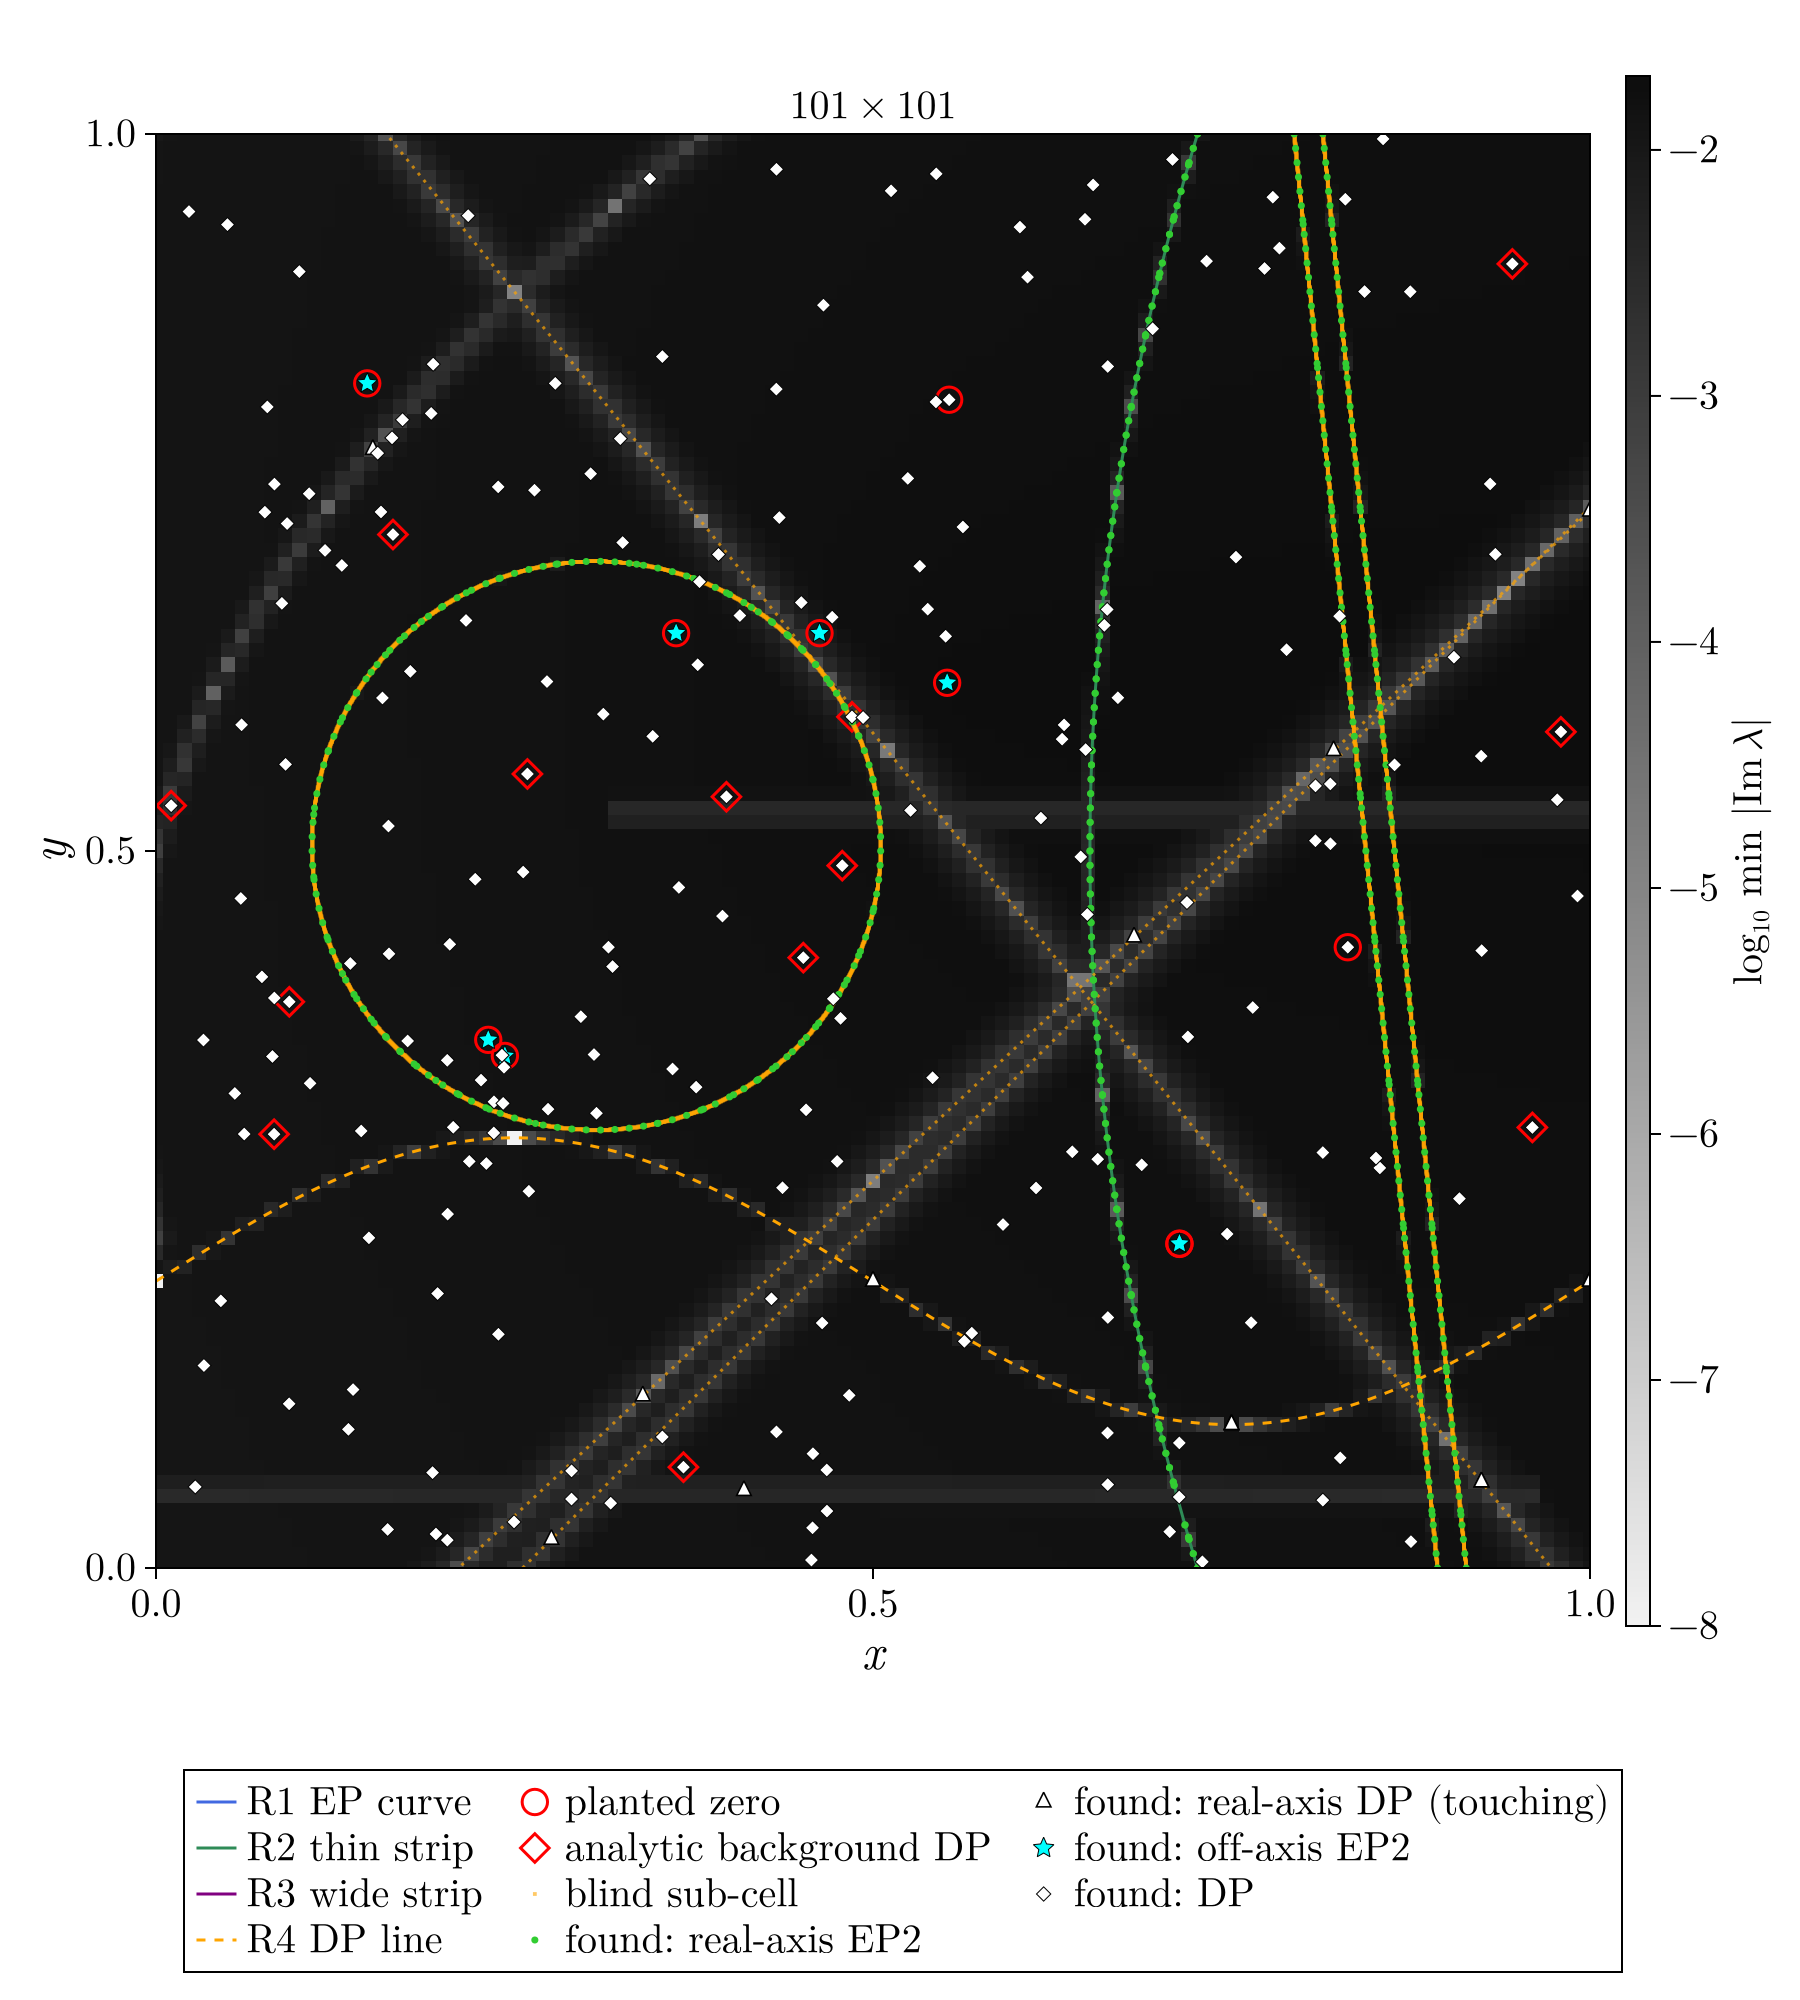

In [ ]:
fig101 = plot_toy(R101; title = L"101\times101")
# save("Julia/NHQRM/toy_map_101.png", fig101; px_per_unit = 3)
fig101

In [46]:
p151 = (x = range(0.0, 1.0, 151), y = range(0.0, 1.0, 151))
toy_kw = (re_window = (-1.0, 0.0), im_cap = 0.05)

R151 = ep_search(toymat, p151; toy_kw...);  jldsave("toy_R151.jld2"; R = R151)
t = R151.meta.timing
println("grid 151×151:  ", length(R151.eps), " EP2, ", length(R151.dps), " DP, ", length(R151.inconclusive), " inconclusive;  time [s]: ",
        "spectra ", round(t.spectra, digits = 1), ", real ", round(t.real, digits = 1), ", off-axis ", round(t.complex, digits = 1),
        ", checks ", round(t.checks + t.records, digits = 1), "  (", R151.meta.nthreads, " threads)")

[1/5] spectra (nodes)             100%|███| Time: 0:00:01 (70.26 μs/it)
[2/5] real axis (grid lines)      100%|███| Time: 0:00:23 (79.34 ms/it)
[3/5] off axis (edge phases)      100%|███| Time: 0:04:52 ( 6.46 ms/it)
[4/5] off axis (cell refinement)  100%|███| Time: 0:03:21 ( 0.26  s/it)
[5/5] checks (approach test)      100%|███| Time: 0:00:25 (21.60 ms/it)


grid 151×151:  924 EP2, 238 DP, 0 inconclusive;  time [s]: spectra 1.6, real 24.0, off-axis 494.2, checks 25.2  (32 threads)


In [47]:
compare(R151, p151; name = "grid 151 × 151")


══════════ grid 151 × 151 ══════════
PASS  R1 circle: 238 / 238 expected EPs found (position < 1e-9)
PASS  R1 circle: 0 found points not on the analytic curves
PASS  R1 circle: verdicts ["EP2"]
PASS  R2 thin strip: 346 / 346 expected EPs found (position < 1e-9)
PASS  R2 thin strip: 0 found points not on the analytic curves
PASS  R2 thin strip: verdicts ["EP2"]
PASS  R3 wide strip: 332 / 332 expected EPs found (position < 1e-9)
PASS  R3 wide strip: 0 found points not on the analytic curves
PASS  R3 wide strip: verdicts ["EP2"]
PASS  R4 + background axis crossings (DPs on the real axis): 0 false EP2 (near misses 1470, touching 1239; real-axis records classified DP: 31)
PASS  C1  EP2, δ² = z                  index 1 (exp. 1), EP2, |Δp| = 3.0e-16, |Δλ| = 7.0e-16, t = 1.0
PASS  C2  EP2, δ² = z̄                  index -1 (exp. -1), EP2, |Δp| = 3.2e-16, |Δλ| = 8.0e-16, t = 1.0
PASS  C3a weak EP2, δ² = z² + t²       index 1 (exp. 1), EP2, |Δp| = 1.1e-16, |Δλ| = 5.6e-16, t = 0.0002
PASS  C3b w

0

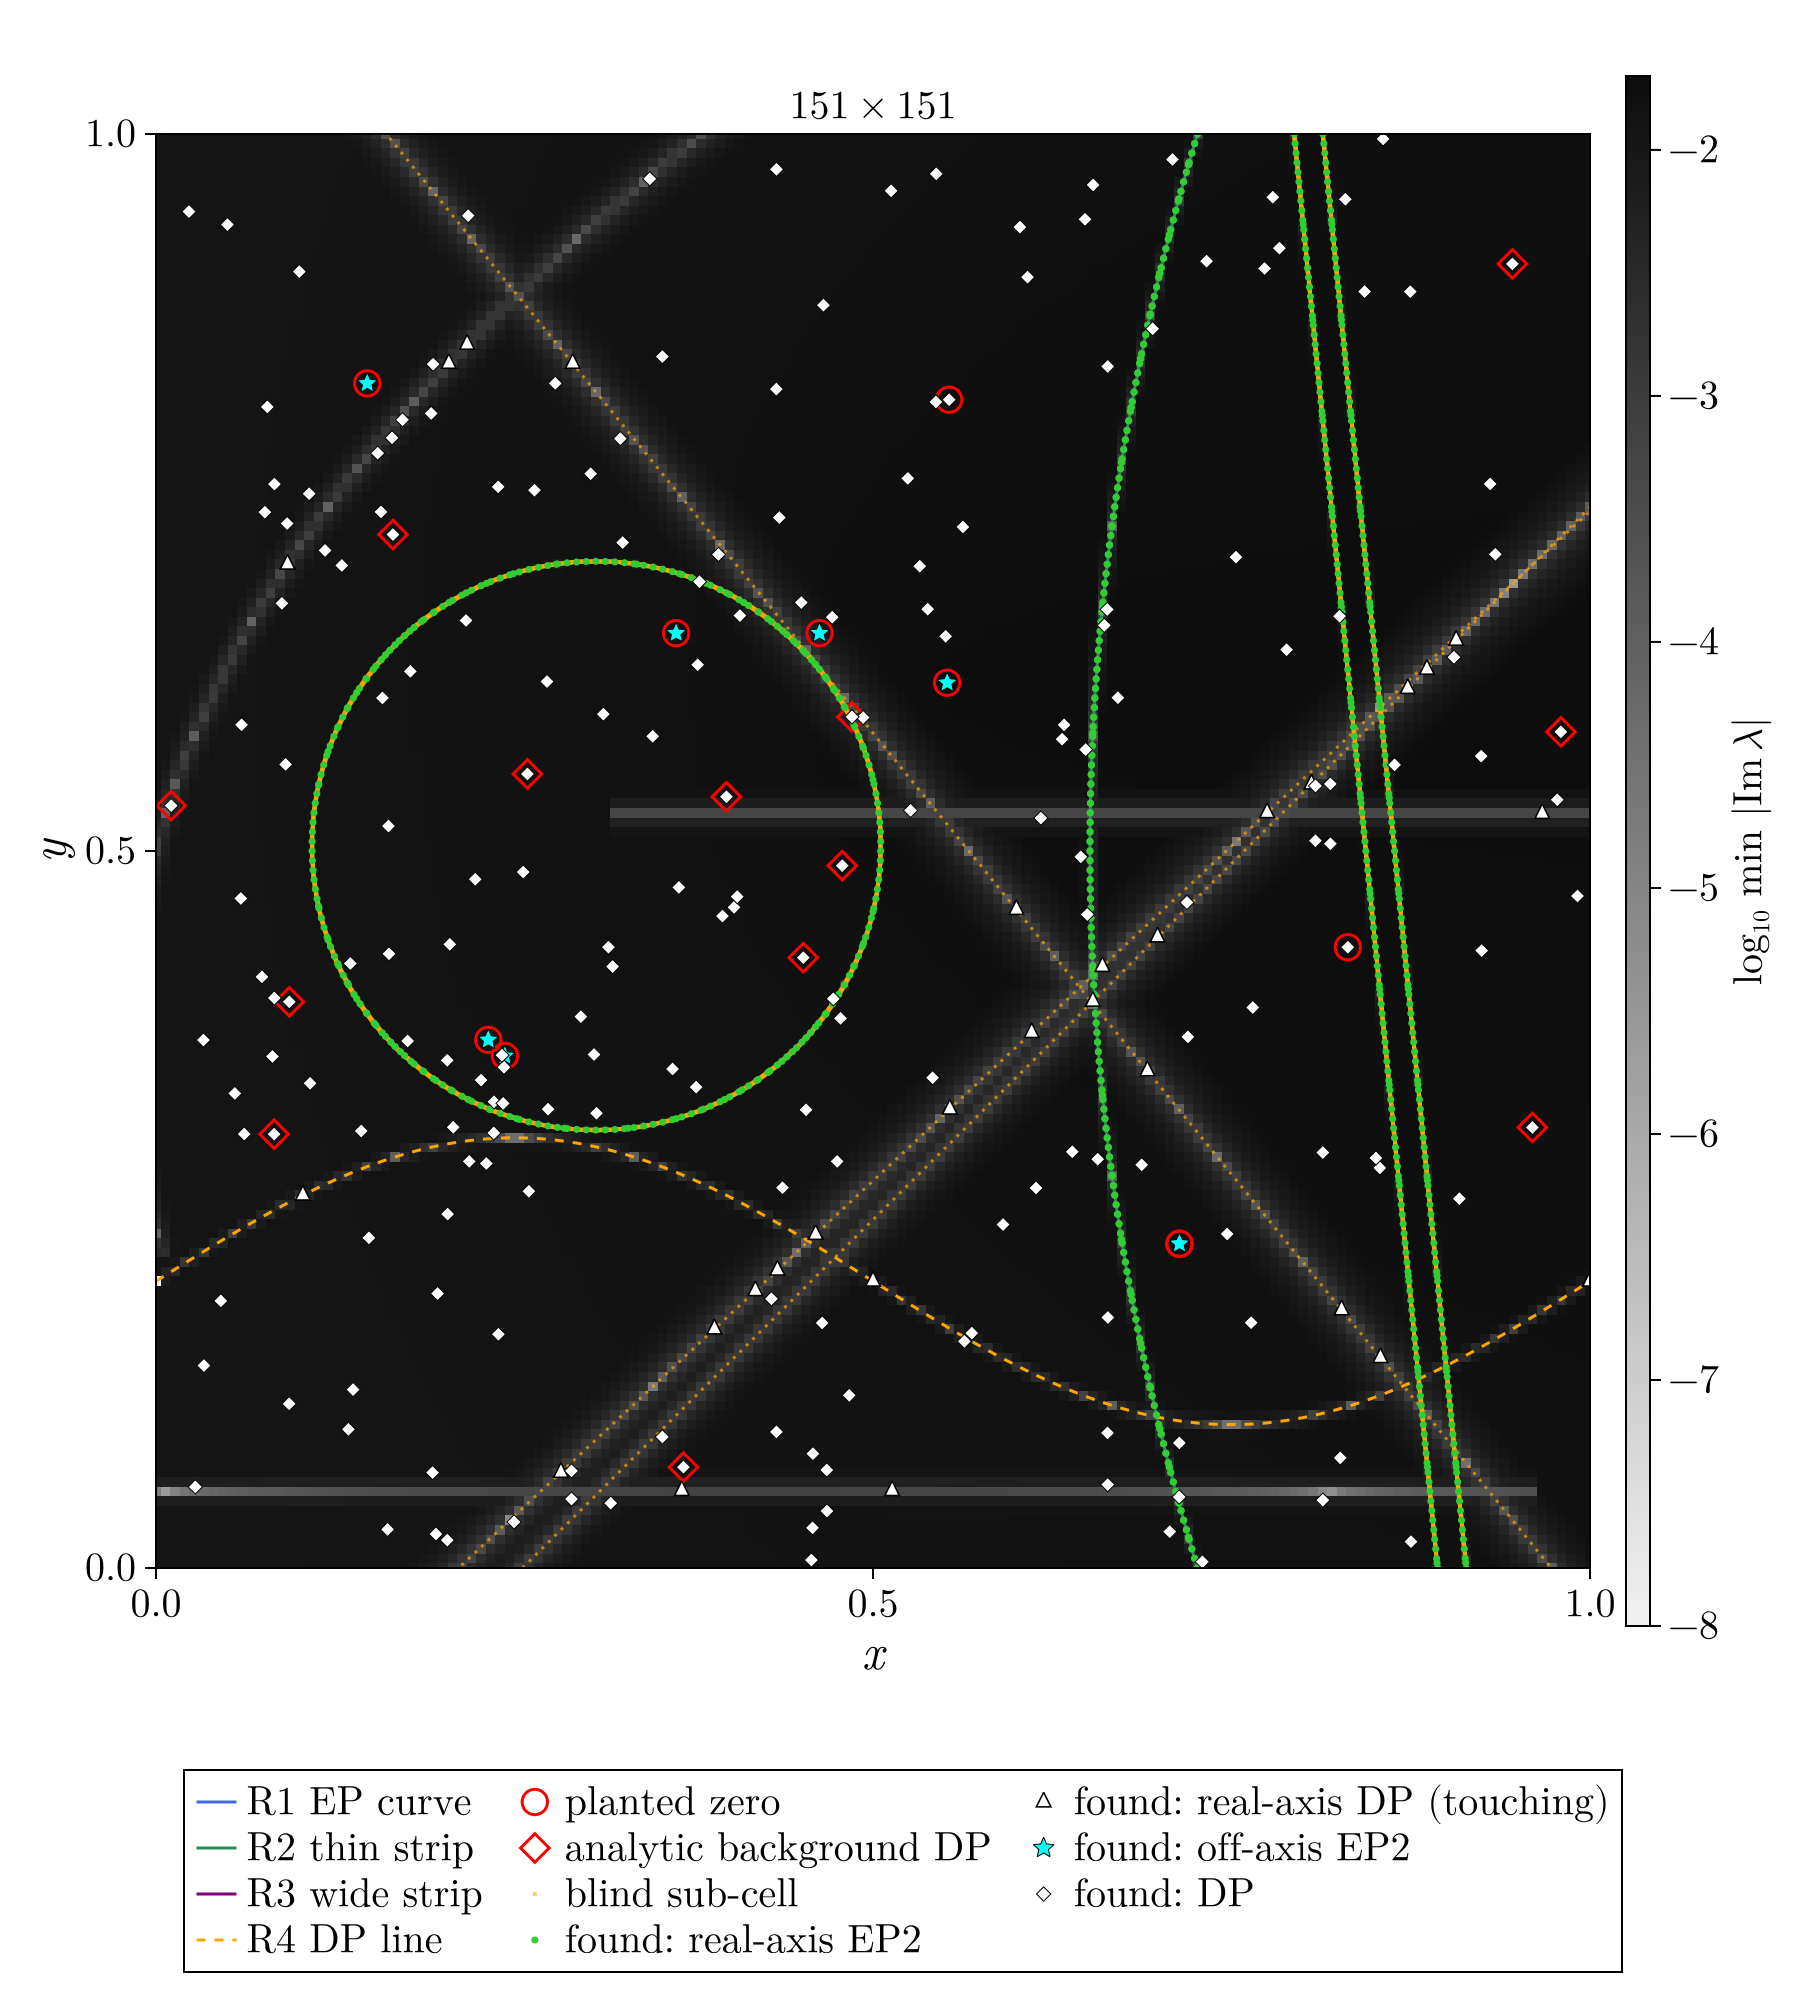

In [45]:
fig151 = plot_toy(R151; title = L"151\times151")
# save("Julia/NHQRM/toy_map_151.png", fig151; px_per_unit = 3)
fig151

## What to look at

- The two `compare` blocks: every line should read `PASS`. A `FAIL` prints the offending items (missed or spurious points, wrong index or verdict, unexplained unreliable cells).
- The timings, to extrapolate the cost of the QRM scans: the real matrix here is $72\times72$, against $128\times128$ for a QRM parity block with $N_\mathrm{trunc}=16$.
- The maps: filled markers (solver) must sit on the analytic curves and inside the hollow markers (planted zeros, analytic background DPs).